# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- **Nama:** Ahmad Nurus Sholihin
- **Email:** ansstatistika295@gmail.com
- **ID Dicoding:** ahmad_nurus_sholihin

## Persiapan

### Menyiapkan library yang dibutuhkan

In [41]:
# Library utama untuk analisis data dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utility untuk menampilkan tabel dengan format notebook
from IPython.display import display
# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import os
import joblib


### Menyiapkan data yang akan diguankan

In [42]:
# link dataset 
url = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/employee/employee_data.csv"
df = pd.read_csv(url)
# simpan dalam excel untuk dasboard
df.to_excel("employee_data.xlsx", index=False)
# Melihat 5 data teratas
print(df.head())

   EmployeeId  Age  Attrition     BusinessTravel  DailyRate  \
0           1   38        NaN  Travel_Frequently       1444   
1           2   37        1.0      Travel_Rarely       1141   
2           3   51        1.0      Travel_Rarely       1323   
3           4   42        0.0  Travel_Frequently        555   
4           5   40        NaN      Travel_Rarely       1194   

               Department  DistanceFromHome  Education EducationField  \
0         Human Resources                 1          4          Other   
1  Research & Development                11          2        Medical   
2  Research & Development                 4          4  Life Sciences   
3                   Sales                26          3      Marketing   
4  Research & Development                 2          4        Medical   

   EmployeeCount  ...  RelationshipSatisfaction StandardHours  \
0              1  ...                         2            80   
1              1  ...                         1     

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [44]:
# Daftar kolom angka yang secara logika adalah kategori / label
kolom_kategori = [
    'EmployeeId', 'Attrition', 'Education', 'EnvironmentSatisfaction', 
    'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'
]

# Mengubah tipe datanya menjadi object (string)
df[kolom_kategori] = df[kolom_kategori].astype('object')

# Mengecek kembali hasilnya
print("--- Tipe Data Setelah Diperbaiki ---")
print(df[kolom_kategori].dtypes)

--- Tipe Data Setelah Diperbaiki ---
EmployeeId                  object
Attrition                   object
Education                   object
EnvironmentSatisfaction     object
JobInvolvement              object
JobLevel                    object
JobSatisfaction             object
PerformanceRating           object
RelationshipSatisfaction    object
StockOptionLevel            object
WorkLifeBalance             object
dtype: object


## Data Understanding

Jumlah baris dan kolom: (1470, 35)

Tipe data tiap kolom:
EmployeeId                  object
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                   object
EducationField              object
EmployeeCount                int64
EnvironmentSatisfaction     object
Gender                      object
HourlyRate                   int64
JobInvolvement              object
JobLevel                    object
JobRole                     object
JobSatisfaction             object
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating           object
RelationshipSatisfaction    object
StandardHours                int

,Age,DailyRate,DistanceFromHome,EmployeeCount,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StandardHours,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,1.0,65.891156,6502.931293,14313.103401,2.693197,15.209524,80.0,11.279592,2.799320,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,0.0,20.329428,4707.956783,7117.786044,2.498009,3.659938,0.0,7.780782,1.289271,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.0,30.000000,1009.000000,2094.000000,0.000000,11.000000,80.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,1.0,48.000000,2911.000000,8047.000000,1.000000,12.000000,80.0,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,1.0,66.000000,4919.000000,14235.500000,2.000000,14.000000,80.0,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,1.0,83.750000,8379.000000,20461.500000,4.000000,18.000000,80.0,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,1.0,100.000000,19999.000000,26999.000000,9.000000,25.000000,80.0,40.000000,6.000000,40.000000,18.000000,15.000000,17.000000



Statistik kategorikal:


,EmployeeId,Attrition,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,Over18,OverTime,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance
count,1470,1058.0,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,1470,2.0,3,3,5,6,4,2,4,5,9,4,3,1,2,2,4,4,4
top,1470,0.0,Travel_Rarely,Research & Development,3,Life Sciences,3,Male,3,1,Sales Executive,4,Married,Y,No,3,3,0,3
freq,1,879.0,1043,961,572,606,453,882,868,543,326,459,673,1470,1054,1244,459,631,893



Jumlah missing value per kolom:


Attrition    412
dtype: int64


Distribusi target 'Attrition':


Attrition
0.0    879
1.0    179
Name: count, dtype: int64

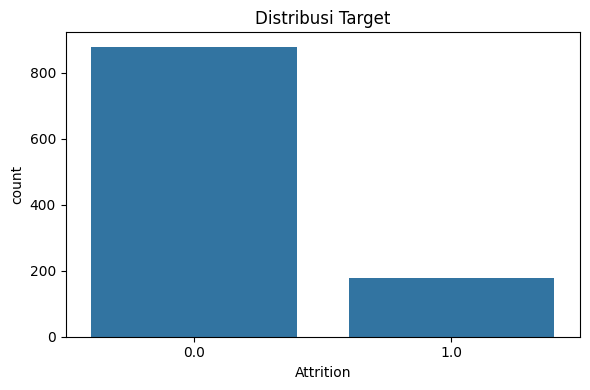

In [45]:
# Menampilkan struktur data
print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data tiap kolom:")
print(df.dtypes)

# Statistik deskriptif
print("\nStatistik numerik:")
display(df.describe())

print("\nStatistik kategorikal:")
display(df.describe(include="object"))

# Cek missing value
missing_values = df.isna().sum().sort_values(ascending=False)
print("\nJumlah missing value per kolom:")
display(missing_values[missing_values > 0])

# Cek distribusi target (jika ada kolom Attrition)
target_candidates = ["Attrition", "attrition"]
target_col = next((c for c in target_candidates if c in df.columns), None)

if target_col is not None:
    print(f"\nDistribusi target '{target_col}':")
    display(df[target_col].value_counts())

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col)
    plt.title("Distribusi Target")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom target Attrition tidak ditemukan. Pastikan nama kolom target sesuai dataset.")

In [46]:
# Membersihkan data
df_prep = df.copy()

# Hapus duplikasi jika ada
before_rows = df_prep.shape[0]
df_prep = df_prep.drop_duplicates()
after_rows = df_prep.shape[0]
print(f"Jumlah baris sebelum drop duplicate: {before_rows}")
print(f"Jumlah baris sesudah drop duplicate: {after_rows}")

# Tentukan kolom target
target_candidates = ["Attrition", "attrition"]
target_col = next((c for c in target_candidates if c in df_prep.columns), None)

if target_col is None:
    raise ValueError("Kolom target tidak ditemukan. Gunakan nama kolom target yang benar.")

# Hapus baris dengan target kosong
before_target_drop = df_prep.shape[0]
df_prep = df_prep.dropna(subset=[target_col]).copy()
after_target_drop = df_prep.shape[0]
print(f"Jumlah baris sebelum drop target kosong: {before_target_drop}")
print(f"Jumlah baris sesudah drop target kosong: {after_target_drop}")
df_prep.to_excel("employee_data_clean.xlsx", index=False)  # Simpan data yang sudah dipreprocess untuk dashboard


Jumlah baris sebelum drop duplicate: 1470
Jumlah baris sesudah drop duplicate: 1470
Jumlah baris sebelum drop target kosong: 1470
Jumlah baris sesudah drop target kosong: 1058


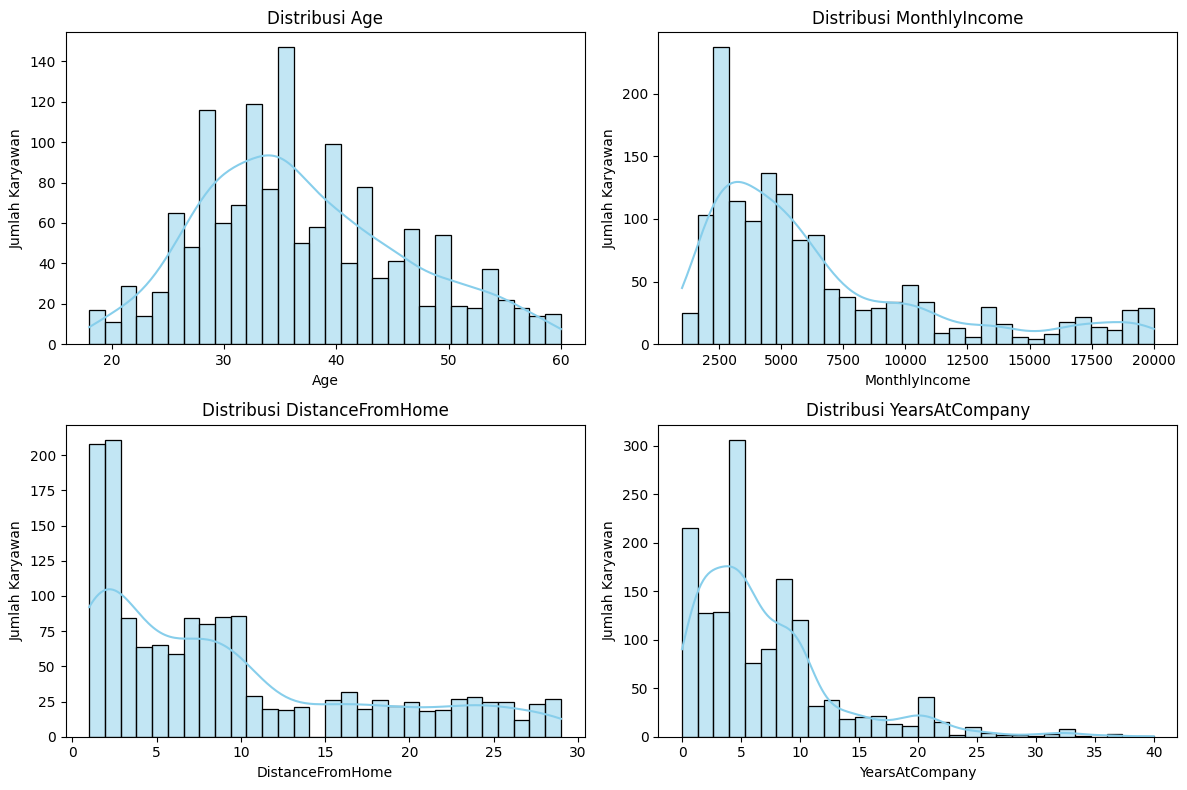

In [47]:
# --- EDA Univariate: Distribusi Kolom Numerik ---
# Mengambil beberapa kolom numerik penting untuk divisualisasikan
num_cols_eda = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols_eda):
    plt.subplot(2, 2, i+1)
    sns.histplot(data=df, x=col, kde=True, color='skyblue', bins=30)
    plt.title(f'Distribusi {col}')
    plt.ylabel('Jumlah Karyawan')
plt.tight_layout()
plt.show()

### Interpretasi Distribusi Fitur Numerik

- Distribusi `Age` berpusat pada usia produktif (sekitar akhir 20-an sampai 40-an).
- `MonthlyIncome` tampak condong ke kanan (*right-skewed*), artinya mayoritas karyawan berada pada rentang gaji menengah ke bawah dengan sedikit karyawan bergaji sangat tinggi.
- `DistanceFromHome` dan `YearsAtCompany` juga menunjukkan sebaran tidak simetris dengan beberapa nilai ekstrem.
- Pola ini mengindikasikan adanya outlier yang perlu diperhatikan saat pemodelan.

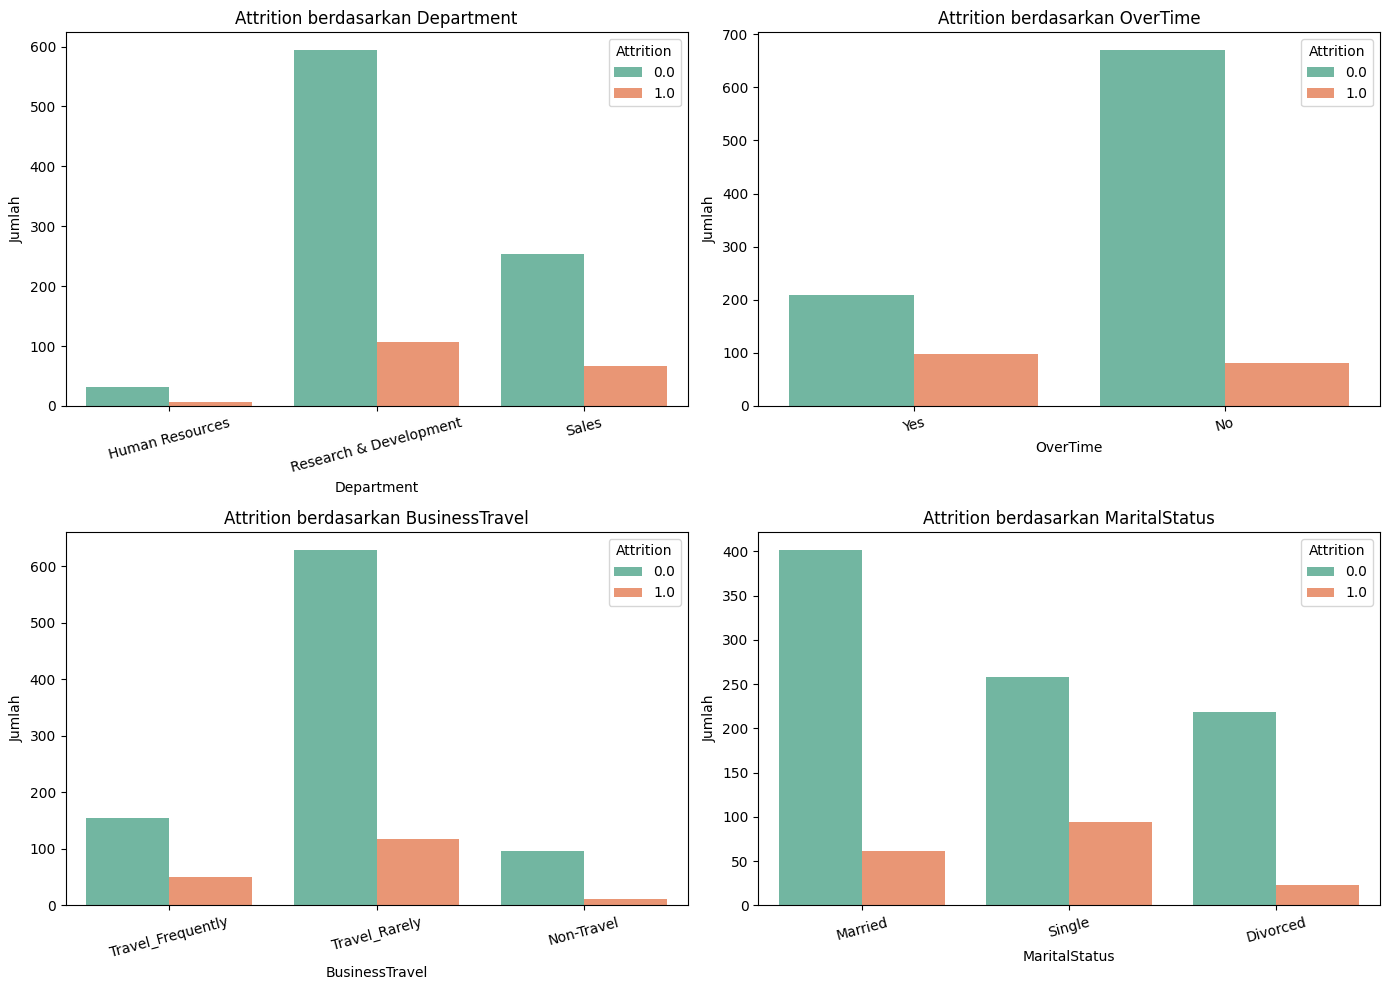

In [48]:
# --- EDA Bivariate: Kategorikal vs Target (Attrition) ---
# Memilih fitur kategorikal yang dicurigai berpengaruh besar
cat_cols_eda = ['Department', 'OverTime', 'BusinessTravel', 'MaritalStatus']

plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols_eda):
    plt.subplot(2, 2, i+1)
    # Jika Attrition masih berbentuk 1.0 dan 0.0, pastikan dikonversi atau divisualisasikan langsung
    sns.countplot(data=df, x=col, hue='Attrition', palette='Set2')
    plt.title(f'Attrition berdasarkan {col}')
    plt.xticks(rotation=15)
    plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

### Interpretasi Kategorikal vs Attrition

- `OverTime = Yes` terlihat memiliki proporsi attrition yang lebih tinggi dibanding `OverTime = No`.
- Pada `MaritalStatus`, kelompok `Single` menunjukkan attrition relatif lebih menonjol.
- Attrition hadir pada beberapa kategori `BusinessTravel`, terutama `Travel_Rarely` dan `Travel_Frequently`.
- Secara umum, variabel kategorikal ini layak dipertimbangkan sebagai prediktor penting.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19596\1515434815.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='Set1')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19596\1515434815.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='Set1')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19596\1515434815.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='Set1')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19596\1515434815.py:5: Futu

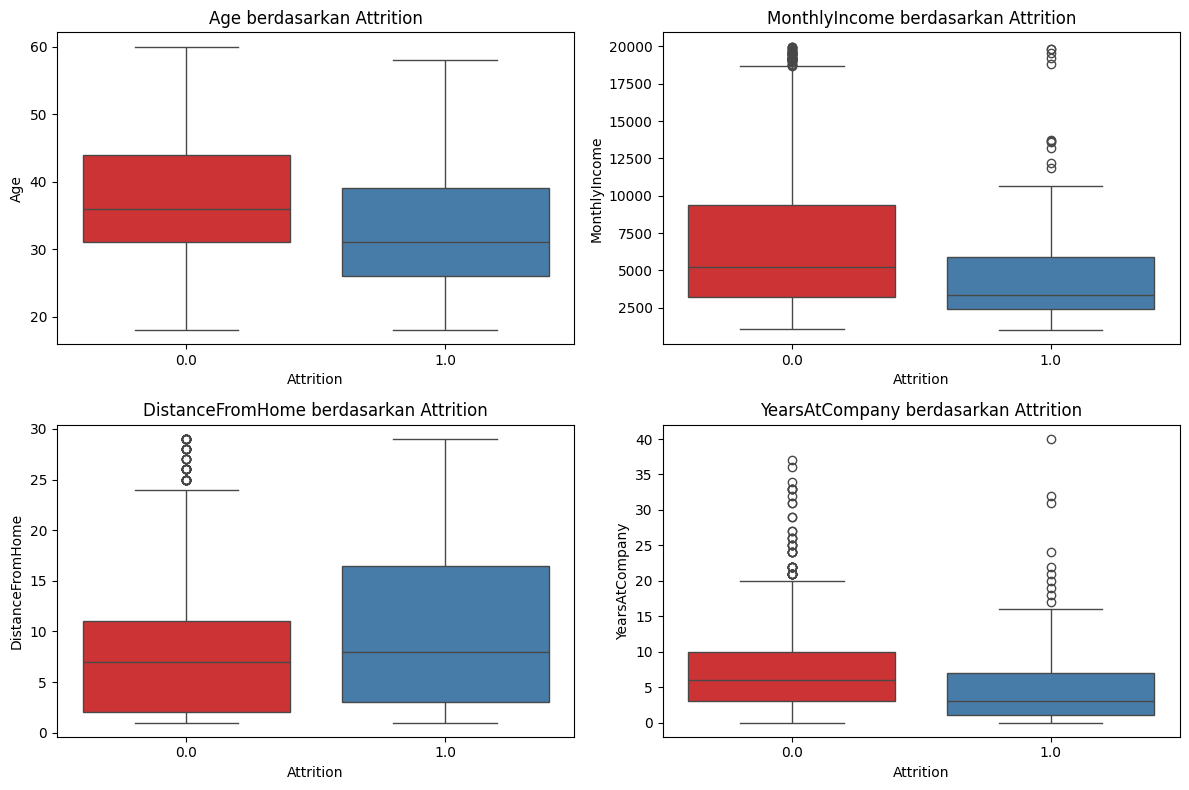

In [49]:
# --- EDA Bivariate: Numerik vs Target (Attrition) menggunakan Boxplot ---
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols_eda): # Menggunakan daftar kolom numerik yang sama dengan di atas
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df, x='Attrition', y=col, palette='Set1')
    plt.title(f'{col} berdasarkan Attrition')
plt.tight_layout()
plt.show()

### Interpretasi Numerik vs Attrition (Boxplot)

- Kelompok `Attrition = 1` cenderung memiliki median `Age` yang lebih rendah (lebih muda).
- `MonthlyIncome` pada kelompok attrition cenderung lebih rendah, walau tetap ada beberapa outlier bernilai tinggi.
- `YearsAtCompany` pada attrition umumnya lebih pendek, mengindikasikan karyawan dengan masa kerja rendah lebih rentan keluar.
- `DistanceFromHome` menunjukkan sebaran yang cukup lebar pada kedua kelas, sehingga pengaruhnya perlu dikonfirmasi lewat model.

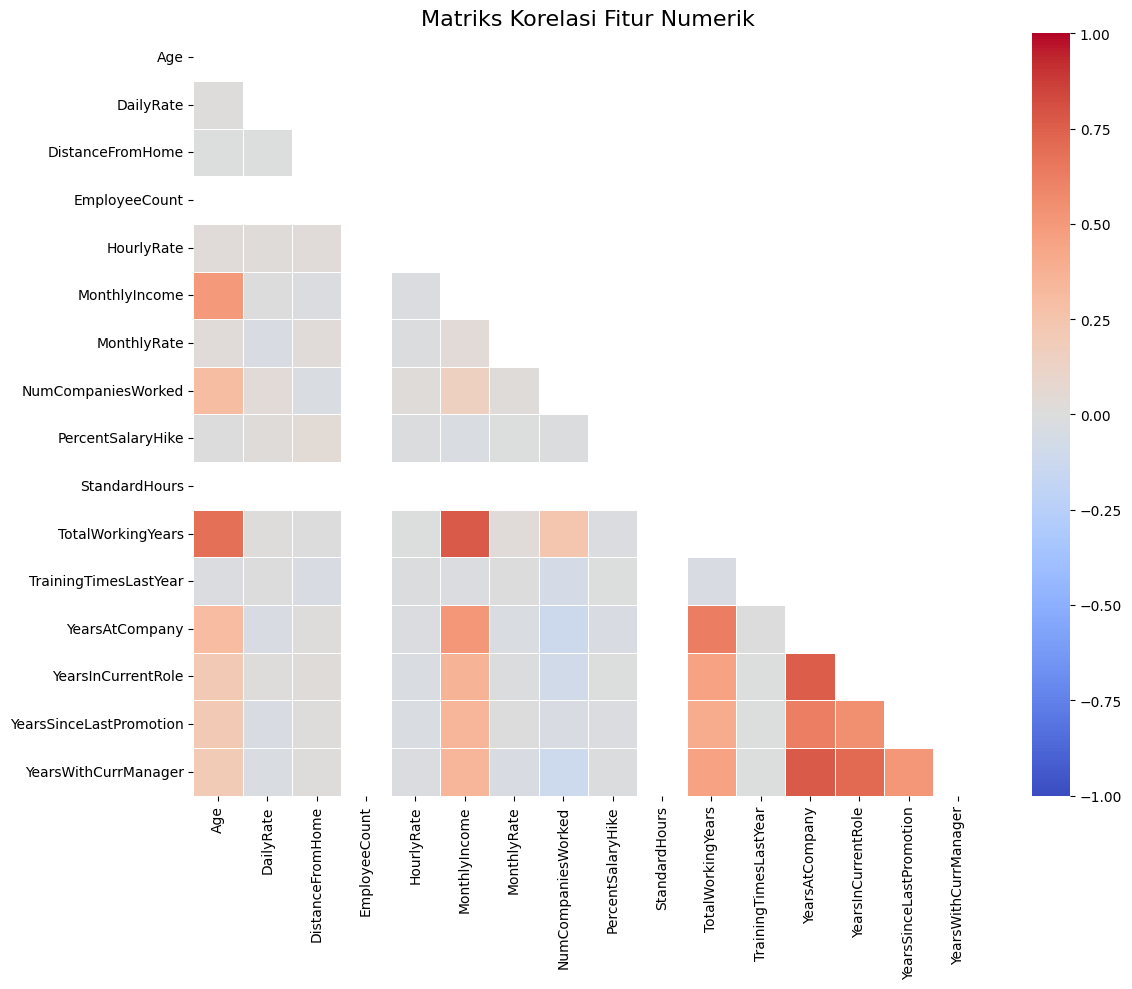

In [50]:
# --- EDA Multivariate: Matriks Korelasi (Numerical) ---
plt.figure(figsize=(12, 10))
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Menghitung korelasi Pearson
corr_matrix = df_numeric.corr()

# Membuat mask agar visualisasi hanya menampilkan setengah segitiga bawah (lebih rapi)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur Numerik', fontsize=16)
plt.tight_layout()
plt.show()

### Interpretasi Matriks Korelasi

- Terlihat korelasi positif yang kuat antar fitur masa kerja seperti `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, dan `YearsSinceLastPromotion`.
- `MonthlyIncome` berkorelasi positif dengan `TotalWorkingYears`.
- Mayoritas pasangan fitur lain menunjukkan korelasi rendah hingga sedang, sehingga informasi antarfitur masih cukup beragam.
- Untuk model yang sensitif terhadap multikolinearitas, fitur masa kerja yang sangat berkorelasi bisa dipertimbangkan untuk seleksi fitur atau regularisasi.

## Data Preparation / Preprocessing

In [51]:
# Pisahkan fitur dan target
X = df_prep.drop(columns=[target_col]).copy()
y = df_prep[target_col].copy()

# Hapus kolom ID lebih dulu sebelum encoding
id_cols = [c for c in X.columns if "id" in c.lower()]
if id_cols:
    X = X.drop(columns=id_cols)
print("Kolom ID yang dihapus:", id_cols)

# Ubah target menjadi biner secara robust untuk tipe numerik/object
y_numeric = pd.to_numeric(y, errors="coerce")
if y_numeric.notna().all():
    y = y_numeric.astype(int)
else:
    y_str = y.astype(str).str.strip().str.lower()
    y = y_str.map({
        "yes": 1, "no": 0,
        "1": 1, "0": 0,
        "1.0": 1, "0.0": 0,
        "true": 1, "false": 0
    })

    if y.isna().any():
        # fallback jika label target tidak sesuai mapping di atas
        y = pd.Series(pd.factorize(df_prep[target_col])[0], index=df_prep.index)

# Pastikan target tanpa missing value
if pd.Series(y).isna().any():
    raise ValueError("Target masih mengandung missing value setelah preprocessing.")

# Tangani missing value fitur
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    mode_value = X[col].mode()[0]
    X[col] = X[col].astype("string").fillna(mode_value)

# Tentukan kolom untuk Label Encoding (ordinal + biner) dan OHE (nominal)
from sklearn.preprocessing import LabelEncoder

ordinal_candidates = {
    "education", "environmentsatisfaction", "jobinvolvement", "joblevel",
    "jobsatisfaction", "performancerating", "relationshipsatisfaction",
    "stockoptionlevel", "worklifebalance"
}
ordinal_cols = [c for c in cat_cols if c.lower() in ordinal_candidates]
binary_cols = [c for c in cat_cols if c not in ordinal_cols and X[c].nunique(dropna=True) == 2]
label_encode_cols = ordinal_cols + binary_cols
ohe_cols = [c for c in cat_cols if c not in label_encode_cols]

# Label encoding untuk fitur ordinal dan biner
for col in label_encode_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# One-hot encoding untuk fitur nominal
X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

print("Kolom Label Encoding:", label_encode_cols)
print("Kolom One-Hot Encoding:", ohe_cols)

# Split train-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran data train:", X_train.shape)
print("Ukuran data test:", X_test.shape)

Kolom ID yang dihapus: ['EmployeeId']
Kolom Label Encoding: ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance', 'Gender', 'OverTime']
Kolom One-Hot Encoding: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus', 'Over18']
Ukuran data train: (846, 46)
Ukuran data test: (212, 46)


## Modeling

In [52]:
# Inisialisasi model
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=42
            ))
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
}

# Training dan evaluasi awal
model_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    model_results.append(result)
    trained_models[model_name] = model

results_df = pd.DataFrame(model_results).sort_values(by="f1", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print(f"Model terbaik (berdasarkan F1): {best_model_name}")

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.716981,0.342105,0.722222,0.464286
1,Random Forest,0.839623,0.750000,0.083333,0.150000


Model terbaik (berdasarkan F1): Logistic Regression


Algoritma **Logistic Regression** terpilih sebagai model terbaik. Model ini difokuskan pada metrik Recall (kemampuan mendeteksi karyawan yang benar-benar akan keluar) dan berhasil mencetak nilai Recall sebesar 72% untuk kelas attrition positif, serta skor ROC-AUC sebesar 0.8048. Angka ini menunjukkan bahwa model memiliki kemampuan diskriminasi yang sangat baik (di atas 80%) dalam membedakan mana karyawan yang akan bertahan dan mana yang berpotensi resign.

## Evaluation

Classification Report:
              precision    recall  f1-score   support

           0     0.9265    0.7159    0.8077       176
           1     0.3421    0.7222    0.4643        36

    accuracy                         0.7170       212
   macro avg     0.6343    0.7191    0.6360       212
weighted avg     0.8272    0.7170    0.7494       212



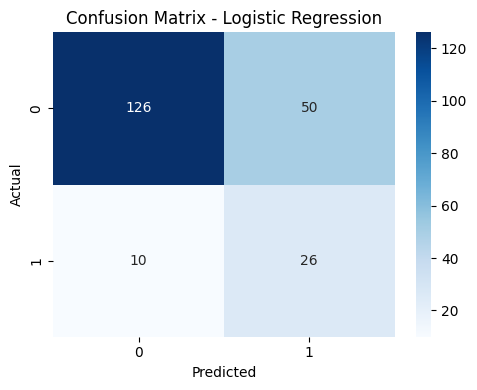

ROC-AUC Score: 0.8048


In [53]:
# Prediksi model terbaik
y_pred_best = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_best, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC-AUC jika model punya predict_proba
if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")
else:
    print("Model tidak mendukung predict_proba, ROC-AUC tidak dihitung.")

In [54]:
# Simpan model terbaik
# Menyimpan model terbaik ke format .pkl
model_filename = 'model.pkl'
joblib.dump(best_model, model_filename)
print(f"\nModel terbaik ({best_model_name}) berhasil disimpan ke '{model_filename}'")


Model terbaik (Logistic Regression) berhasil disimpan ke 'model.pkl'
